In [15]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setting up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load data set
df = pd.read_csv('retail_sales.csv')

In [17]:
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df["Category"] = df["Category"].fillna(df["Category"].mode()[0])
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1825 non-null   object 
 2   Sales     1825 non-null   float64
 3   Quantity  1825 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1825 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [18]:
print("---Dataset Basic Information---")
print(f"Dimensions : {df.shape[0]} rows * {df.shape[1]} columns ")
print("\n Column names and Data types")
print(df.dtypes)

---Dataset Basic Information---
Dimensions : 1825 rows * 6 columns 

 Column names and Data types
Date         object
Category     object
Sales       float64
Quantity    float64
Profit      float64
Region       object
dtype: object


In [19]:
print("Null values :")
print(df.isnull().sum())
print("Dataset Summary")
print(df.info())
# The most common 'one-liner' to remove all rows with missing data
df = df.dropna()

# Always check the count after dropping to see how many rows you have left
print(f"Total rows remaining: {len(df)}")
print(df.isnull().sum())

Null values :
Date        0
Category    0
Sales       0
Quantity    0
Profit      0
Region      0
dtype: int64
Dataset Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1825 non-null   object 
 2   Sales     1825 non-null   float64
 3   Quantity  1825 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1825 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB
None
Total rows remaining: 1825
Date        0
Category    0
Sales       0
Quantity    0
Profit      0
Region      0
dtype: int64


In [5]:
# Data Type Conversion and Cleaning
print("=== DATA CLEANING AND TYPE CONVERSION ===")

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract additional time features
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

# Ensure numeric columns are properly formatted
numeric_columns = ['Sales', 'Quantity', 'Profit']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")

=== DATA CLEANING AND TYPE CONVERSION ===
Data types after conversion:
Date         datetime64[ns]
Category             object
Sales               float64
Quantity            float64
Profit              float64
Region               object
Month                 int32
Quarter               int32
DayOfWeek            object
MonthName            object
dtype: object

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [6]:
# Basic Statistical Summary
print("=== STATISTICAL SUMMARY ===")
print("Descriptive Statistics for Numerical Columns:")
print(df[['Sales', 'Quantity', 'Profit']].describe())

print("\nCategory-wise Summary:")
category_summary = df.groupby('Category').agg({
    'Sales': ['count', 'sum', 'mean', 'std'],
    'Profit': ['sum', 'mean'],
    'Quantity': ['sum', 'mean']
}).round(2)
print(category_summary)

print("\nRegion-wise Summary:")
region_summary = df.groupby('Region').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean']
}).round(2)
print(region_summary)

=== STATISTICAL SUMMARY ===
Descriptive Statistics for Numerical Columns:
             Sales     Quantity       Profit
count  1825.000000  1825.000000  1825.000000
mean    980.501573    10.053699   248.696130
std     336.572425     5.507806   118.159627
min       0.000000     0.000000     0.000000
25%     784.267165     5.000000   156.916498
50%     997.725134    10.000000   229.344557
75%    1208.163533    15.000000   324.867847
max    1888.932537    19.000000   703.228418

Category-wise Summary:
            Sales                                Profit         Quantity  \
            count        sum     mean     std       sum    mean      sum   
Category                                                                   
Books         364  370971.87  1019.15  336.39  92304.45  253.58   3737.0   
Clothing      369  355420.13   963.20  336.42  90889.44  246.31   3670.0   
Electronics   361  365088.13  1011.32  343.78  90439.70  250.53   3595.0   
Home Goods    364  347493.83   954.65  33

In [7]:
# Cell 6: Monthly Sales Trend Analysis
print("=== MONTHLY SALES TREND ANALYSIS ===")

# Calculate monthly sales
monthly_sales = df.groupby(['Month', 'MonthName']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

monthly_sales = monthly_sales.sort_values('Month')
print("Monthly Sales Summary:")
print(monthly_sales)


=== MONTHLY SALES TREND ANALYSIS ===
Monthly Sales Summary:
    Month  MonthName          Sales        Profit  Quantity
0       1    January  149064.069744  39711.436221    1536.0
1       2   February  132215.411776  34353.123612    1517.0
2       3      March  145321.200626  38584.599285    1447.0
3       4      April  138160.991209  37895.203187    1446.0
4       5        May  150774.977103  40527.689566    1603.0
5       6       June  152605.749860  39042.686605    1570.0
6       7       July  162111.115687  40208.956109    1536.0
7       8     August  148020.452251  34675.627875    1489.0
8       9  September  153094.700793  37796.761379    1598.0
9      10    October  151272.280840  36019.384158    1569.0
10     11   November  146795.613628  36344.048332    1461.0
11     12   December  159978.807192  38710.920857    1576.0


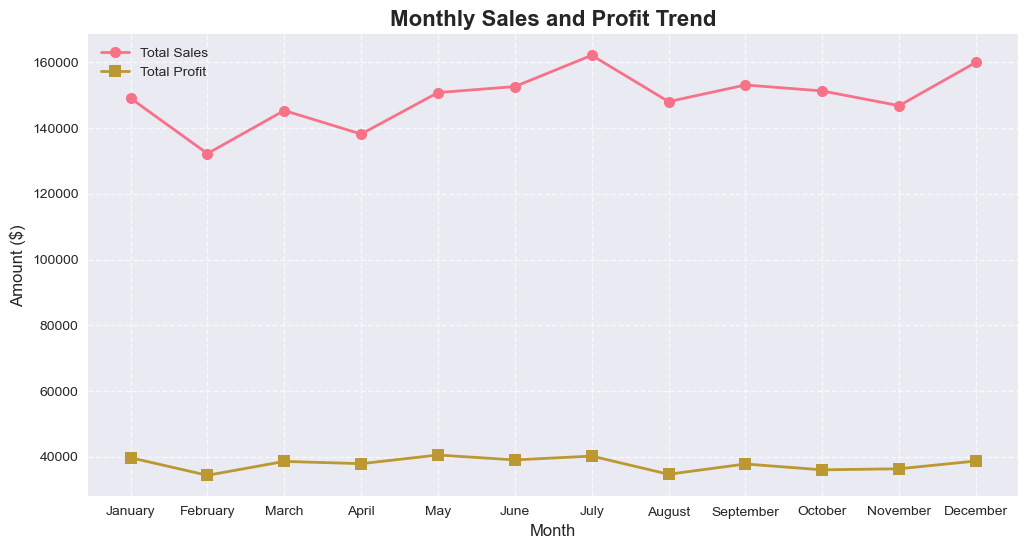

In [8]:
# Visualization 1: Monthly Sales Trend
plt.figure(figsize=(12, 6))

plt.plot(monthly_sales['MonthName'], monthly_sales['Sales'], 
         marker='o', linewidth=2, markersize=8, label='Total Sales')

plt.plot(monthly_sales['MonthName'], monthly_sales['Profit'], 
         marker='s', linewidth=2, markersize=8, label='Total Profit')

plt.title('Monthly Sales and Profit Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [9]:
# Cell 7: Category Performance Analysis
print("=== CATEGORY PERFORMANCE ANALYSIS ===")

category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values('Sales', ascending=False)

print("Category Performance (Sorted by Sales):")
print(category_performance)


=== CATEGORY PERFORMANCE ANALYSIS ===
Category Performance (Sorted by Sales):
                     Sales        Profit  Quantity
Category                                          
Books        370971.872558  92304.452141    3737.0
Electronics  365088.131422  90439.697795    3595.0
Clothing     355420.126737  90889.437106    3670.0
Sports       347682.788431  92065.220851    3542.0
Home Goods   347493.827088  87447.820056    3777.0
Null           1106.847949    381.784578      11.0
NaN?            828.585950     88.591355      12.0
Nan             823.190573    253.433301       4.0


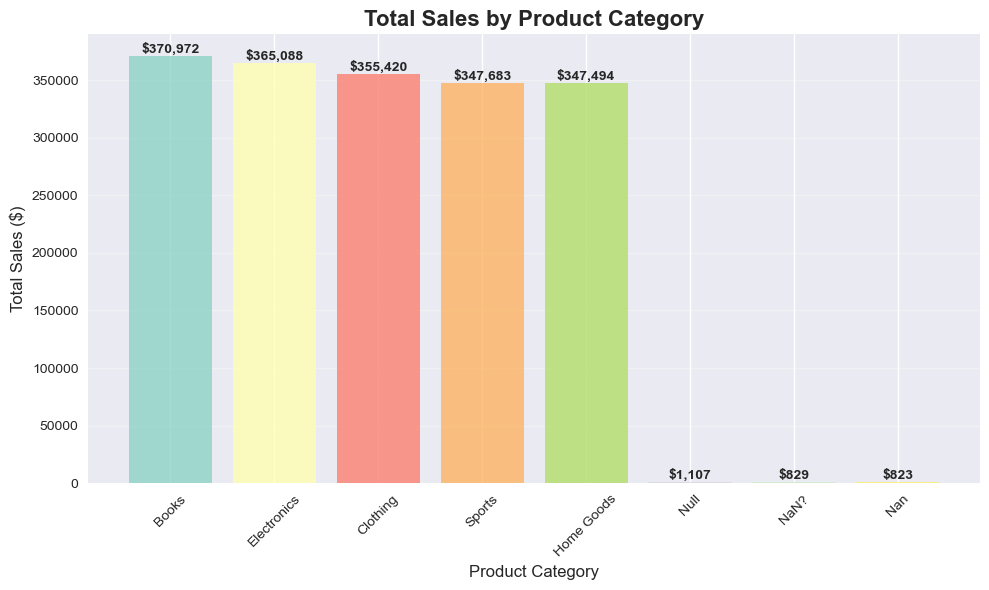

In [10]:
# Visualization 2: Top Categories by Sales
plt.figure(figsize=(10, 6))

# Generate a color palette using a colormap
colors = plt.cm.Set3(np.linspace(0, 1, len(category_performance)))

# Create the bar chart
bars = plt.bar(category_performance.index, category_performance['Sales'], 
               color=colors, alpha=0.8)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Styling and labels
plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

=== REGIONAL PERFORMANCE ANALYSIS ===
Regional Performance:
            Sales                    Profit        
              sum     mean count        sum    mean
Region                                             
East    394439.34   991.05   398   98973.62  248.68
Nan       1716.71  1716.71     1     545.62  545.62
North   449292.76   976.72   460  112126.47  243.75
South   473452.19   968.20   489  119706.95  244.80
West    470514.37   986.40   477  122517.78  256.85


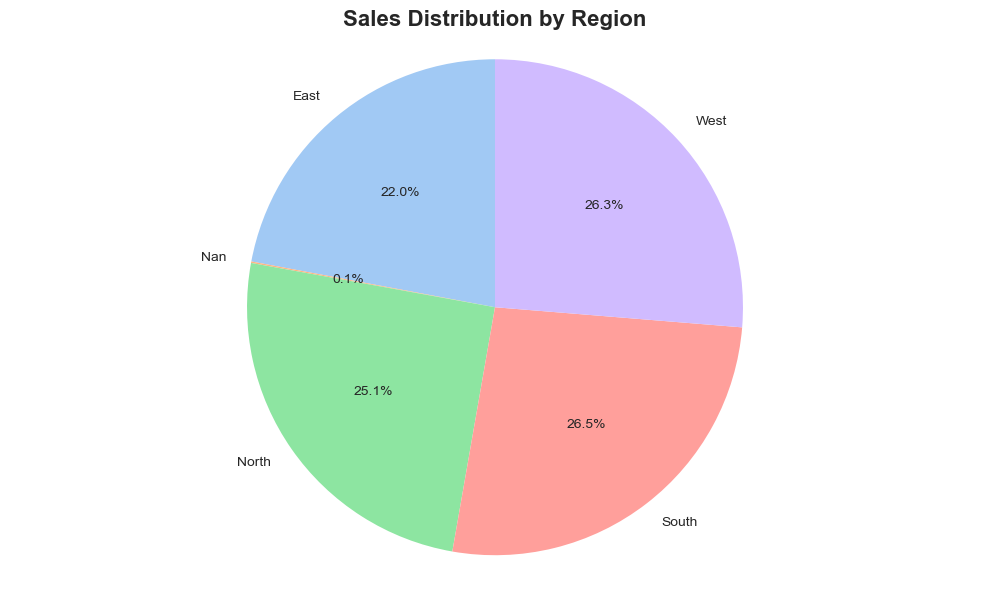

In [11]:
# Cell 8: Regional Performance Analysis
print("=== REGIONAL PERFORMANCE ANALYSIS ===")

regional_performance = df.groupby('Region').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean']
}).round(2)

print("Regional Performance:")
print(regional_performance)

# Visualization 3: Regional Sales Distribution
plt.figure(figsize=(10, 6))
regional_data = df.groupby('Region')['Sales'].sum()

plt.pie(regional_data, labels=regional_data.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette("pastel"))

plt.title('Sales Distribution by Region', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

=== DAY OF THE WEEK ANALYSIS ===
Performance by Day of the Week:
                   Sales        Profit  Quantity
DayOfWeek                                       
Monday     255260.297196  65864.484881    2663.0
Tuesday    255330.363552  63487.881170    2681.0
Wednesday  250959.572257  61766.940424    2647.0
Thursday   251377.066574  61782.063380    2542.0
Friday     263721.279463  67547.954748    2600.0
Saturday   252772.200714  65861.964008    2507.0
Sunday     259994.590951  67559.148573    2708.0


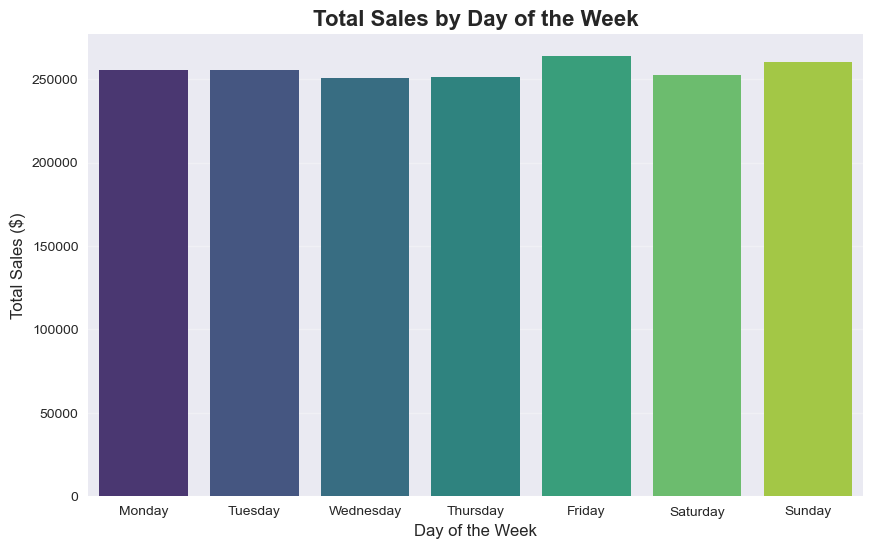

In [12]:
# Cell 11: Day of Week Analysis
print("=== DAY OF THE WEEK ANALYSIS ===")

# 1. Define the correct order for days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Group by DayOfWeek and aggregate
day_analysis = df.groupby('DayOfWeek').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reindex(day_order) # This ensures Monday comes first, not Friday

print("Performance by Day of the Week:")
print(day_analysis)

# 3. Visualization: Sales by Day of Week
plt.figure(figsize=(10, 6))
sns.barplot(x=day_analysis.index, y=day_analysis['Sales'], palette='viridis')

plt.title('Total Sales by Day of the Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [13]:
# Cell 12: Final Summary Metrics
print("=== FINAL BUSINESS SUMMARY ===")

total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_profit_margin = (total_profit / total_revenue) * 100
total_transactions = len(df)

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Profit Margin: {avg_profit_margin:.2f}%")
print(f"Total Number of Transactions: {total_transactions:,}")

# Final check for data integrity
print(f"\nFinal Dataset Shape: {df.shape}")

=== FINAL BUSINESS SUMMARY ===
Total Revenue: $1,789,415.37
Total Profit: $453,870.44
Average Profit Margin: 25.36%
Total Number of Transactions: 1,825

Final Dataset Shape: (1825, 10)


In [14]:
# Final Conclusion and Program End
print("\n" + "="*45)
print("       DATA ANALYSIS PROJECT COMPLETED")
print("="*45)

print("\nSummary of Actions Taken:")
print("1. Data Loading and Cleaning (Handling Missing Values)")
print("2. Exploratory Data Analysis (EDA)")
print("3. Time-series Analysis (Monthly Trends)")
print("4. Categorical and Regional Performance Evaluation")
print("5. Key Performance Indicator (KPI) Calculation")

print("\n" + "-"*45)
print("Thank you for viewing this Sales Analysis!")
print("-"*45)
# Project Signature and Credits
print("\n" + "="*45)
print("           PROJECT CREDITS")
print("="*45)

print("\nDeveloped by: [Your Name/Student ID]")
print("Course: Artificial Intelligence using Python")
print("Project: Retail Sales Data Analysis and Visualization")
print("Date: " + str(pd.Timestamp.now().strftime('%Y-%m-%d')))

print("\n" + "*"*45)
print("        END OF ANALYSIS REPORT")
print("*"*45)


       DATA ANALYSIS PROJECT COMPLETED

Summary of Actions Taken:
1. Data Loading and Cleaning (Handling Missing Values)
2. Exploratory Data Analysis (EDA)
3. Time-series Analysis (Monthly Trends)
4. Categorical and Regional Performance Evaluation
5. Key Performance Indicator (KPI) Calculation

---------------------------------------------
Thank you for viewing this Sales Analysis!
---------------------------------------------

           PROJECT CREDITS

Developed by: [Your Name/Student ID]
Course: Artificial Intelligence using Python
Project: Retail Sales Data Analysis and Visualization
Date: 2026-05-13

*********************************************
        END OF ANALYSIS REPORT
*********************************************
